<a id="title"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:20px 20px;">**ASOCA Segment Labeling Exploration**</p>

## Method Overview

This notebook inspects the ASOCA segment-label volume (now split by cohort) and answers three practical questions:

1. What is the image geometry and spatial metadata?
2. Is this file a categorical label map (integer IDs)?
3. Where are the labeled voxels and how do they look in 2D slices?

It supports the new folder structure:
- `data/ASOCA Normal Labels`
- `data/ASOCA Diseased Labels`

The output is a compact exploratory workflow aligned with the style used in the other project notebooks.

<a id="step1"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">1. Imports & Configuration</p>

This section imports dependencies and resolves the correct label folder from the patient ID.

In [2]:
# Purpose: import libraries and configure paths for ASOCA label exploration.
from pathlib import Path

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

PATIENT_ID = "Normal_1"  # e.g., "Normal_1" or "Diseased_1"

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "data").is_dir():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise RuntimeError(
            "Could not locate project root containing the data/ directory. "
            "Run Jupyter with the working directory inside the repository."
        )
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / "data"


def resolve_label_path(patient_id: str, data_root: Path) -> Path:
    """Resolve label file from split normal/diseased label folders."""
    patient_lower = patient_id.lower()
    normal_dir = data_root / "ASOCA Normal Labels"
    diseased_dir = data_root / "ASOCA Diseased Labels"

    if patient_lower.startswith("normal_"):
        return normal_dir / f"{patient_id}.nii.gz"
    if patient_lower.startswith("diseased_"):
        return diseased_dir / f"{patient_id}.nii.gz"

    candidates = [
        normal_dir / f"{patient_id}.nii.gz",
        diseased_dir / f"{patient_id}.nii.gz",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return candidates[0]


LABEL_PATH = resolve_label_path(PATIENT_ID, DATA_ROOT)

print(f"Patient ID   : {PATIENT_ID}")
print(f"Project root : {PROJECT_ROOT}")
print(f"Label path   : {LABEL_PATH}")
print(f"Exists       : {LABEL_PATH.exists()}")

Patient ID   : Normal_1
Project root : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository
Label path   : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\data\ASOCA Normal Labels\Normal_1.nii.gz
Exists       : True


<a id="step2"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">2. NIfTI Loading & Metadata Inspection</p>

Load the label volume and inspect core spatial metadata (`shape`, `dtype`, `affine`, spacing, and header transform codes).

In [3]:
# Purpose: load NIfTI and inspect geometry/header metadata.
if not LABEL_PATH.exists():
    raise FileNotFoundError(f"File not found: {LABEL_PATH}")

img = nib.load(str(LABEL_PATH))
arr = img.get_fdata()
arr_int = np.rint(arr).astype(np.int32)

print("=== NIfTI Metadata ===")
print(f"Shape (Z, Y, X)      : {arr.shape}")
print(f"Data dtype in file   : {img.get_data_dtype()}")
print(f"Intensity min / max  : {arr.min():.3f} / {arr.max():.3f}")
print(f"Affine:\n{img.affine}")

hdr = img.header
print("\n=== Header Spatial Info ===")
print(f"Voxel spacing        : {hdr.get_zooms()[:3]}")
print(f"qform_code / sform_code: {int(hdr['qform_code'])} / {int(hdr['sform_code'])}")

=== NIfTI Metadata ===
Shape (Z, Y, X)      : (512, 512, 204)
Data dtype in file   : int16
Intensity min / max  : 0.000 / 19.000
Affine:
[[-0.41601601  0.          0.         -0.        ]
 [ 0.         -0.41601601  0.         -0.        ]
 [ 0.          0.          0.625       0.        ]
 [ 0.          0.          0.          1.        ]]

=== Header Spatial Info ===
Voxel spacing        : (np.float32(0.416016), np.float32(0.416016), np.float32(0.625))
qform_code / sform_code: 1 / 1


### Quick interpretation of the metadata

- **Shape `(Z, Y, X)`**: number of voxels along each axis (the 3D grid size).
- **Intensity range (0 to 19 here)**: label IDs stored in each voxel (`0` = background, non-zero = segment class).
- **Voxel spacing**: physical size of one voxel in mm (`dx`, `dy`, `dz`).
- **Affine (4x4 matrix)**: transform that maps voxel coordinates `(i, j, k)` to real-world coordinates `(x, y, z)` in mm, including orientation and scale.

So this file is a **multiclass label volume**: same voxel-grid structure as a binary mask, but each vessel voxel can carry a segment ID instead of only 0/1.

<a id="step3"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">3. Label Distribution Analysis</p>

Check whether the image behaves as a segment label map by listing unique values and counting voxels per non-zero label.

In [5]:
# Purpose: summarize label IDs and voxel counts.
unique_vals, counts = np.unique(arr_int, return_counts=True)

print("=== Label Distribution ===")
print(f"Unique values count   : {len(unique_vals)}")
print(f"First 15 unique values: {unique_vals[:20]}")

nonzero_mask = unique_vals != 0
nonzero_labels = unique_vals[nonzero_mask]
nonzero_counts = counts[nonzero_mask]

print(f"\nNon-zero labels count : {len(nonzero_labels)}")
for value, count in zip(nonzero_labels[:40], nonzero_counts[:40]):
    print(f"Label {int(value):>3}: {int(count):>8} voxels")

if len(nonzero_labels) > 40:
    print("... (truncated)")

=== Label Distribution ===
Unique values count   : 17
First 15 unique values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 15 17 19]

Non-zero labels count : 16
Label   1:     3012 voxels
Label   2:     6692 voxels
Label   3:     5205 voxels
Label   4:      907 voxels
Label   5:     1780 voxels
Label   6:     2909 voxels
Label   7:      795 voxels
Label   8:     3562 voxels
Label   9:      159 voxels
Label  10:      587 voxels
Label  11:     1734 voxels
Label  12:     2925 voxels
Label  13:     1057 voxels
Label  15:     3203 voxels
Label  17:      352 voxels
Label  19:     1225 voxels


### Quick interpretation of Section 3 results

- **`Unique values count = 17`** means the volume contains 17 distinct voxel values in total.
- **`Non-zero labels count = 16`** excludes the background value `0`.
- So yes: the "missing" label is exactly **`0`**, which is expected in segmentation label maps.

In this sample, labels present are:
- background: `0`
- segment IDs: `1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 17, 19`

Notice that some IDs (for example `14`, `16`, `18`) do not appear in this case. That is normal under the **SCCT-18** 18-segment atlas: those classes exist in the global dictionary (`src/segment_atlas.py`) but are simply absent for this specific patient/sample.

<a id="step5"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">4. Labeled Region Bounding Box</p>

Locate where non-zero labels exist and visualize a representative slice within that bounding region.

=== Bounding box of labeled voxels ===
z: 147 -> 399
y: 129 -> 366
x: 33 -> 177


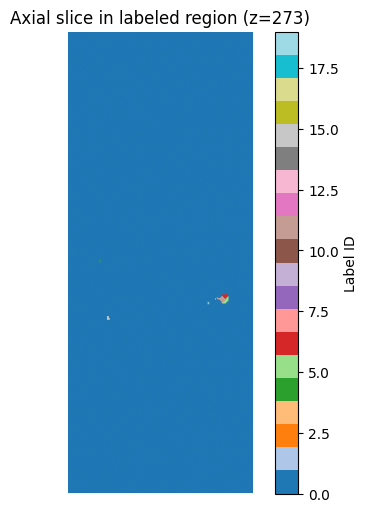

In [7]:
# Purpose: compute non-zero bounding box and inspect one informative slice.
nonzero_voxels = np.argwhere(arr_int > 0)

if len(nonzero_voxels) == 0:
    print("No non-zero labels found in this volume.")
else:
    z_min, y_min, x_min = nonzero_voxels.min(axis=0)
    z_max, y_max, x_max = nonzero_voxels.max(axis=0)

    print("=== Bounding box of labeled voxels ===")
    print(f"z: {z_min} -> {z_max}")
    print(f"y: {y_min} -> {y_max}")
    print(f"x: {x_min} -> {x_max}")

    z_show = int((z_min + z_max) // 2)
    plt.figure(figsize=(6, 6))
    plt.imshow(arr_int[z_show, :, :], cmap="tab20")
    plt.title(f"Axial slice in labeled region (z={z_show})")
    plt.axis("off")
    plt.colorbar(label="Label ID")
    plt.show()